# 02 — SegFormer Demo (Phase 2)

What this covers:
1. Load pretrained SegFormer-b0 (Cityscapes weights)
2. Run inference on a nuScenes front-camera image
3. Visualise pseudo labels (BEV GT projected onto image)
4. Compare zero-shot Cityscapes vs pseudo-label supervision
5. Check label density — how many pixels get labeled

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from utils.config import SEGFORMER, CLASSES
from utils.device import get_device

device = get_device(verbose=True)
print('Ready')

[device] Using: mps
[device] Apple MPS backend active - M3 GPU will be used.
Ready


## 1. Load SegFormer (pretrained Cityscapes weights)

In [2]:
from models.segformer.model import build_segformer

# This downloads ~15 MB of weights on first run
model = build_segformer(pretrained=True).to(device)
model.eval()

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Parameters: {n_params:.1f}M')
print(f'Output classes: {model.decode_head.classifier.out_channels}')

Parameters: 3.7M
Output classes: 5


## 2. Load a nuScenes front-camera image

Image shape: (900, 1600, 3)


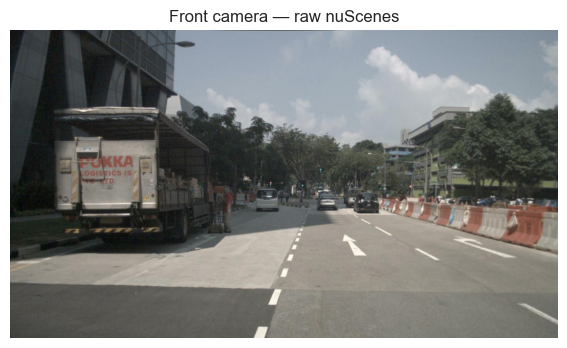

In [3]:
from data.nuscenes_loader import get_all_sample_tokens, get_camera_data

token    = get_all_sample_tokens()[0]
cam_data = get_camera_data(token)

bgr = cv2.imread(str(cam_data['image_path']))
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

print(f'Image shape: {rgb.shape}')
plt.figure(figsize=(12, 4))
plt.imshow(rgb)
plt.title('Front camera — raw nuScenes')
plt.axis('off')
plt.show()

## 3. Run inference — zero-shot (Cityscapes weights, no fine-tuning)

Mask shape: (512, 1024)  dtype: uint8
Classes predicted: [0, 1, 2, 3, 4]


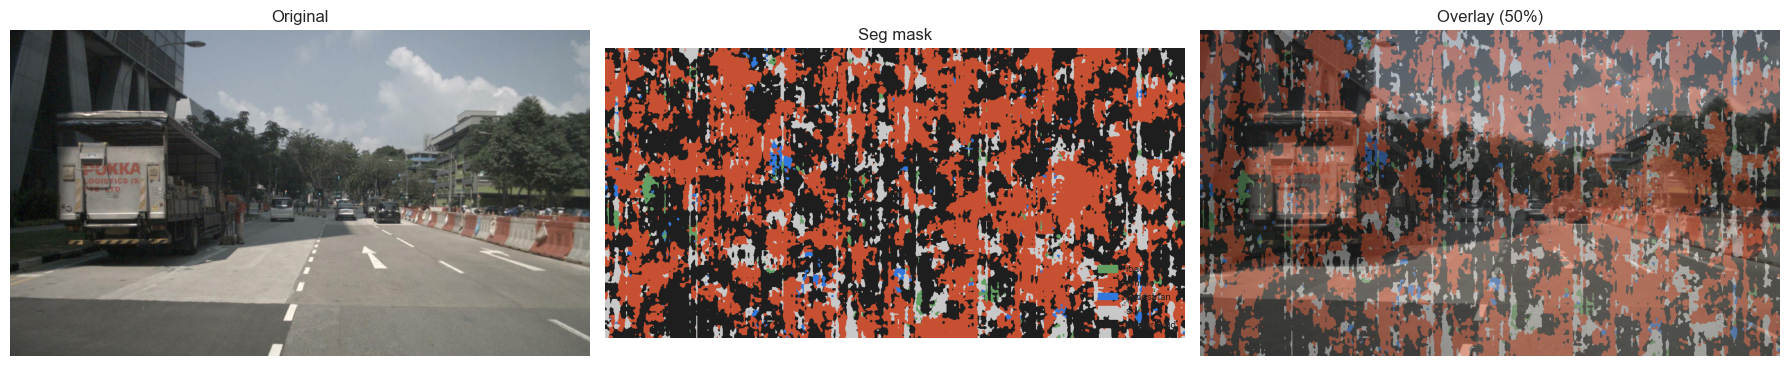

In [4]:
from models.segformer.inference import run_inference
from viz.colorize import colorize_seg, overlay_seg

seg_mask = run_inference(model, bgr, device)
print(f'Mask shape: {seg_mask.shape}  dtype: {seg_mask.dtype}')
print(f'Classes predicted: {np.unique(seg_mask).tolist()}')

seg_rgb = colorize_seg(seg_mask)
overlay  = overlay_seg(rgb, seg_mask, alpha=0.5)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].imshow(rgb);      axes[0].set_title('Original');         axes[0].axis('off')
axes[1].imshow(seg_rgb);  axes[1].set_title('Seg mask');         axes[1].axis('off')
axes[2].imshow(overlay);  axes[2].set_title('Overlay (50%)');    axes[2].axis('off')

cls_names = ['road', 'vehicle', 'pedestrian', 'sky', 'background']
colors    = [[100,160,100],[200,80,50],[50,120,220],[200,200,200],[30,30,30]]
patches   = [mpatches.Patch(color=np.array(c)/255, label=n)
             for c, n in zip(colors, cls_names)]
axes[1].legend(handles=patches, loc='lower right', fontsize=7)
plt.tight_layout()
plt.show()

## 4. Generate pseudo labels (Option B — BEV GT projected to image)

In [5]:
from data.pseudo_labels import generate_pseudo_label, IGNORE
import time

t0    = time.time()
label = generate_pseudo_label(token)
t1    = time.time()

labeled  = (label != IGNORE).sum()
total    = label.size
density  = labeled / total * 100

print(f'Generated in {(t1-t0)*1000:.0f} ms')
print(f'Labeled pixels: {labeled} / {total} ({density:.1f}%)')
print(f'Values present: {np.unique(label).tolist()}  (255=ignore)')

Generated in 150 ms
Labeled pixels: 212862 / 524288 (40.6%)
Values present: [0, 1, 2, 255]  (255=ignore)


## 5. Visualise pseudo labels vs model prediction

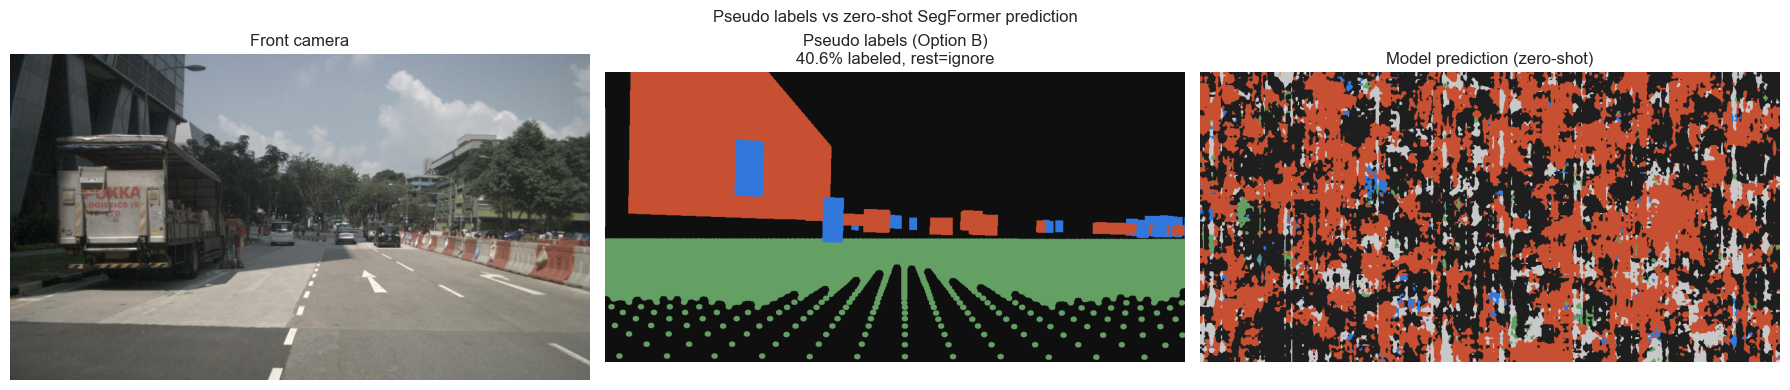

Note: pseudo labels are sparse by design — only pixels where BEV GT
projects cleanly to image plane get labeled. The 255=ignore regions
are excluded from the loss during fine-tuning.


In [6]:
# Pseudo label image — ignore pixels shown as black
pseudo_vis = label.copy().astype(np.float32)
pseudo_vis[label == IGNORE] = 6   # map ignore → background color for display

from viz.colorize import colorize_seg
pseudo_rgb = colorize_seg(pseudo_vis.astype(np.uint8))

# darken ignore pixels so they're visually distinct
ignore_px  = label == IGNORE
pseudo_rgb[ignore_px] = [15, 15, 15]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].imshow(rgb)
axes[0].set_title('Front camera')
axes[0].axis('off')

axes[1].imshow(pseudo_rgb)
axes[1].set_title(f'Pseudo labels (Option B)\n{density:.1f}% labeled, rest=ignore')
axes[1].axis('off')

axes[2].imshow(seg_rgb)
axes[2].set_title('Model prediction (zero-shot)')
axes[2].axis('off')

plt.suptitle('Pseudo labels vs zero-shot SegFormer prediction')
plt.tight_layout()
plt.show()

print('Note: pseudo labels are sparse by design — only pixels where BEV GT')
print('projects cleanly to image plane get labeled. The 255=ignore regions')
print('are excluded from the loss during fine-tuning.')

## 6. Pseudo label density across multiple samples

Generating labels:   0%|          | 0/20 [00:00<?, ?it/s]

Mean label density : 36.5%
Min                : 27.9%
Max                : 52.7%


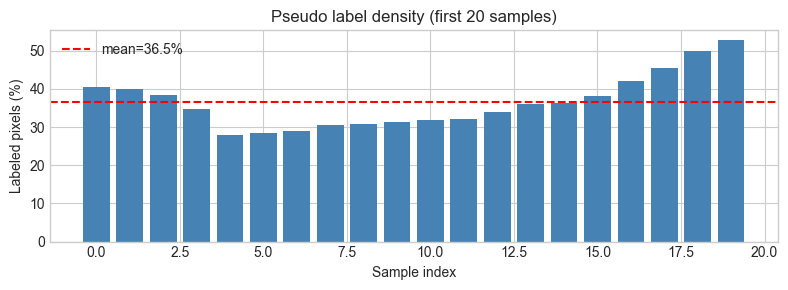

In [7]:
from data.nuscenes_loader import get_all_sample_tokens
from tqdm.notebook import tqdm

tokens    = get_all_sample_tokens()[:20]   # first 20 samples
densities = []

for t in tqdm(tokens, desc='Generating labels'):
    lbl = generate_pseudo_label(t)
    densities.append((lbl != IGNORE).mean() * 100)

print(f'Mean label density : {np.mean(densities):.1f}%')
print(f'Min                : {np.min(densities):.1f}%')
print(f'Max                : {np.max(densities):.1f}%')

plt.figure(figsize=(8, 3))
plt.bar(range(len(densities)), densities, color='steelblue')
plt.axhline(np.mean(densities), color='red', linestyle='--', label=f'mean={np.mean(densities):.1f}%')
plt.xlabel('Sample index')
plt.ylabel('Labeled pixels (%)')
plt.title('Pseudo label density (first 20 samples)')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Class distribution in pseudo labels

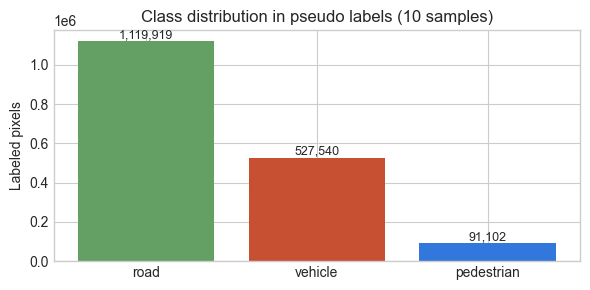

Heavy road imbalance is expected — class weights in config.py compensate.


In [8]:
from collections import Counter

# count labeled pixels by class across 10 samples
cls_counts = Counter()
for t in get_all_sample_tokens()[:10]:
    lbl = generate_pseudo_label(t)
    for c in [0, 1, 2]:
        cls_counts[c] += int((lbl == c).sum())

cls_names = ['road', 'vehicle', 'pedestrian']
counts    = [cls_counts[c] for c in range(3)]
colors_bar = [[100/255,160/255,100/255],
              [200/255,80/255,50/255],
              [50/255,120/255,220/255]]

plt.figure(figsize=(6, 3))
bars = plt.bar(cls_names, counts, color=colors_bar)
plt.title('Class distribution in pseudo labels (10 samples)')
plt.ylabel('Labeled pixels')
for bar, cnt in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{cnt:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print('Heavy road imbalance is expected — class weights in config.py compensate.')

## Summary

If all cells ran clean:
- SegFormer loads and produces (H, W) masks ✓
- Pseudo labels are sparse but non-empty ✓
- Road class dominates (expected, weights fix this) ✓

Run verification before training:
```bash
python scripts/verify_phase2.py
```

Then start fine-tuning:
```bash
bash scripts/run_training_segformer.sh
```

Monitor with:
```bash
tensorboard --logdir runs/segformer_finetune
```

In [9]:
from models.segformer.model import build_segformer_zero_shot

model = build_segformer_zero_shot().to(device)
model.eval()
print("Zero-shot model loaded — 19 Cityscapes classes, no fine-tuning")

Zero-shot model loaded — 19 Cityscapes classes, no fine-tuning


19-class unique: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
5-class  unique: [0, 1, 2, 3, 4]
3-class  unique: [0, 1, 2, 255]  (255=ignore)


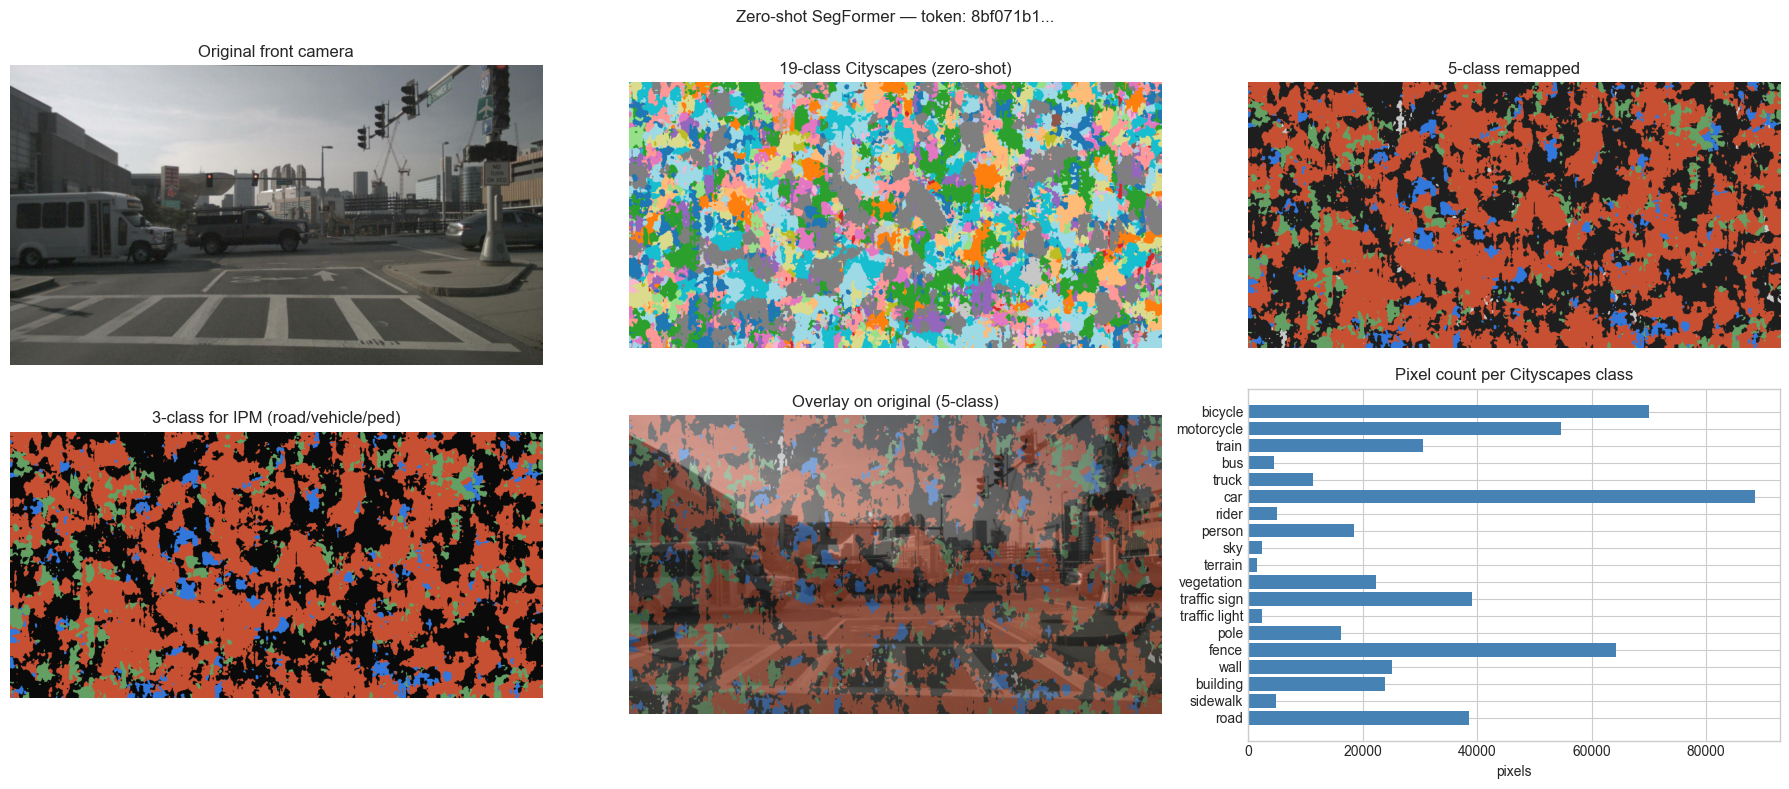

In [16]:
import cv2, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from data.nuscenes_loader import get_all_sample_tokens, get_camera_data
from models.segformer.inference import run_inference_19class, run_inference_5class, run_inference_3class
from data.class_mappings import CITYSCAPES_19_NAMES
from viz.colorize import colorize_seg, overlay_seg

# pick a sample
token    = get_all_sample_tokens()[89]   # change index to see different scenes
cam_data = get_camera_data(token)
bgr      = cv2.imread(str(cam_data["image_path"]))
rgb      = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

# run all three
mask_19 = run_inference_19class(model, bgr, device)
mask_5  = run_inference_5class(model, bgr, device)
mask_3  = run_inference_3class(model, bgr, device)

print(f"19-class unique: {np.unique(mask_19).tolist()}")
print(f"5-class  unique: {np.unique(mask_5).tolist()}")
print(f"3-class  unique: {np.unique(mask_3).tolist()}  (255=ignore)")

# ── 19-class colormap (tab20) ──
cmap = plt.colormaps["tab20"].resampled(19)
vis_19 = (cmap(mask_19)[:, :, :3] * 255).astype(np.uint8)

# ── 5-class colormap ──
vis_5 = colorize_seg(mask_5)

# ── 3-class: road=green, vehicle=orange, ped=blue, ignore=black ──
palette_3 = {0: (100,160,100), 1: (200,80,50), 2: (50,120,220), 255: (10,10,10)}
vis_3 = np.zeros((*mask_3.shape, 3), dtype=np.uint8)
for cls, col in palette_3.items():
    vis_3[mask_3 == cls] = col

overlay = overlay_seg(rgb, mask_5, alpha=0.5)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

axes[0,0].imshow(rgb)
axes[0,0].set_title("Original front camera")
axes[0,0].axis("off")

axes[0,1].imshow(vis_19)
axes[0,1].set_title("19-class Cityscapes (zero-shot)")
axes[0,1].axis("off")

axes[0,2].imshow(vis_5)
axes[0,2].set_title("5-class remapped")
axes[0,2].axis("off")

axes[1,0].imshow(vis_3)
axes[1,0].set_title("3-class for IPM (road/vehicle/ped)")
axes[1,0].axis("off")

axes[1,1].imshow(overlay)
axes[1,1].set_title("Overlay on original (5-class)")
axes[1,1].axis("off")

# class distribution bar chart
classes_present, counts = np.unique(mask_19, return_counts=True)
names = [CITYSCAPES_19_NAMES[c] for c in classes_present]
axes[1,2].barh(names, counts, color="steelblue")
axes[1,2].set_title("Pixel count per Cityscapes class")
axes[1,2].set_xlabel("pixels")

plt.suptitle(f"Zero-shot SegFormer — token: {token[:8]}...", fontsize=12)
plt.tight_layout()
plt.show()